In [166]:
import seaborn as sns
import pandas as pd
from matplotlib.colors import LinearSegmentedColormap
import numpy as np

In [167]:
# order to show the metrics and hippocampal layers

metric_order = [
    "presynapse_image_mfi", 
    "pre_staining_area_um2",
    "pre_puncta_density_per_100_um2",
    "pre_mean_puncta_size_um2",
    "postsynapse_image_mfi",
    "post_staining_area_um2",
    "post_puncta_density_per_100_um2",
    "post_mean_puncta_size_um2",
    "local_peak_colocalized_spots",
    "pearson_cor",
    "overlap_coeff",
    "overlap_um2"
    ]

vlgut1_hippocampal_layer_order = [
    "CA1 SO",
    "CA1 SR",
    "CA1 SLM",
    "CA3 SO",
    "CA3 SL",
    "CA3 SR",
    "DG ML",
    "DG Hilus"
    ]

vlgut2_hippocampal_layer_order = [
    "Subiculum SP",
    "CA2 SP",
    "DG GC",
    "Cortex L4"
    ]

In [169]:
# reading in the VGLUT1-PSD95 dataset
df = pd.read_csv("/Volumes/KINGSTON/data/phd/image-analysis/synapse-counting/GPR37L1/GPR37L1-LacZ_VGLUT1-PSD95_output_data/all_statistics.csv").set_index(['Unnamed: 0'])
df.head(10)

,hippocampal_layer,metric,p_value,statistical significant?
Unnamed: 0,,,,
0,CA1 SO,overlap_um2,0.168625,No
1,CA1 SO,pearson_cor,0.663899,No
2,CA1 SO,overlap_coeff,0.102008,No
3,CA1 SO,local_peak_colocalized_spots,0.829852,No
4,CA1 SO,presynapse_image_mfi,0.350425,No
5,CA1 SO,postsynapse_image_mfi,0.105210,No
6,CA1 SO,pre_puncta_density_per_100_um2,0.832029,No
7,CA1 SO,post_puncta_density_per_100_um2,0.452804,No
8,CA1 SO,pre_staining_area_um2,0.367039,No


In [170]:
df_2 = df.pivot(index="metric", columns="hippocampal_layer", values="p_value").reindex(metric_order)
df_2 = df_2[vlgut1_hippocampal_layer_order]
df_2.head(15)

hippocampal_layer,CA1 SO,CA1 SR,CA1 SLM,CA3 SO,CA3 SL,CA3 SR,DG ML,DG Hilus
metric,,,,,,,,
presynapse_image_mfi,0.350425,0.273257,0.355068,0.584214,0.397673,0.436278,0.612759,0.364659
pre_staining_area_um2,0.367039,0.780123,0.166189,0.859552,0.673375,0.009264,0.098946,0.636606
pre_puncta_density_per_100_um2,0.832029,0.672638,0.093195,0.312945,0.118663,0.005325,0.159163,0.787191
pre_mean_puncta_size_um2,0.044460,0.633252,0.742294,0.645628,0.805850,0.022639,0.306383,0.446559
postsynapse_image_mfi,0.105210,0.708242,0.583949,0.308827,0.506013,0.311291,0.233510,0.797861
post_staining_area_um2,0.737136,0.728603,0.294158,0.466880,0.729865,0.705745,0.745665,0.735584
post_puncta_density_per_100_um2,0.452804,0.441238,0.006424,0.498749,0.606609,0.399208,0.221585,0.527951
post_mean_puncta_size_um2,0.110105,0.317928,0.223754,0.987025,0.824763,0.227647,0.361642,0.887293
local_peak_colocalized_spots,0.829852,0.387665,0.731957,0.725759,0.764703,0.278319,0.380198,0.537730


/var/folders/p5/hzbdgkws2lvg79nyhlq_g_sm0000gn/T/ipykernel_98293/3175312408.py:11: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  annotations = df_2.applymap(lambda x: f'{x:.4f}' if x < 0.1 else '')


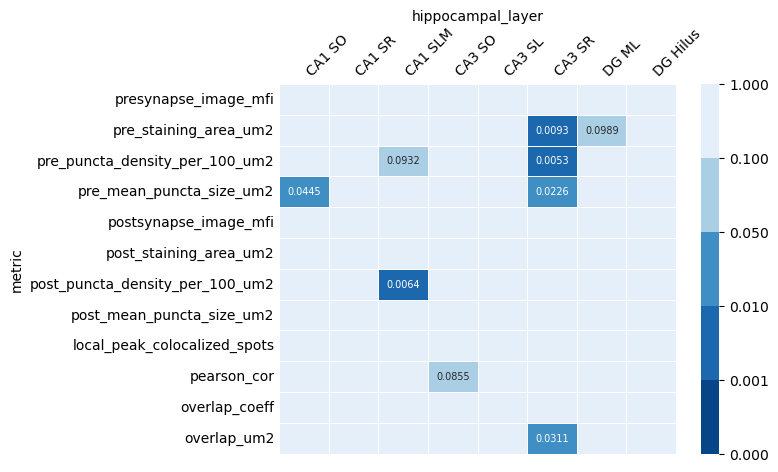

In [171]:
# myColors = ((0.8, 0.0, 0.0, 1.0), (0.0, 0.8, 0.0, 1.0), (0.0, 0.0, 0.8, 1.0))
# cmap = LinearSegmentedColormap.from_list('Custom', myColors, len(myColors))
# cmap = sns.color_palette('RdBu_r', n_colors = 5)

from matplotlib.colors import ListedColormap, BoundaryNorm
import matplotlib.pyplot as plt
cmap = ListedColormap(['#084488', '#1b68ae', '#3f8ec4', '#aacfe5', "#e5eff9"])
norm = BoundaryNorm([0, 0.001, 0.01, 0.05, 0.1, 1], cmap.N)

mask = df_2 < 0.1
annotations = df_2.applymap(lambda x: f'{x:.4f}' if x < 0.1 else '')


ax = sns.heatmap(data=df_2, annot=annotations, fmt = "", annot_kws={"fontsize": 7}, linewidth=0.5, vmin=0, vmax=0.1, cmap=cmap, norm=norm)

ax.xaxis.set_label_position('top')
ax.xaxis.tick_top()
plt.xticks(rotation=45, ha='left')
ax.tick_params(axis='x', length=0)
ax.tick_params(axis='y', length=0)

plt.show()

In [172]:
df_vglut2 = pd.read_csv("/Volumes/KINGSTON/data/phd/image-analysis/synapse-counting/GPR37L1/GPR37L1-LacZ_VGLUT2-PSD95_output_data/all_statistics.csv").set_index(['Unnamed: 0'])
df_vglut2.head(20)

,hippocampal_layer,metric,p_value,statistical significant?
Unnamed: 0,,,,
0,CA2 SP,overlap_um2,0.830845,No
1,CA2 SP,pearson_cor,0.317401,No
2,CA2 SP,overlap_coeff,0.961844,No
3,CA2 SP,local_peak_colocalized_spots,0.965299,No
4,CA2 SP,presynapse_image_mfi,0.672212,No
5,CA2 SP,postsynapse_image_mfi,0.774840,No
6,CA2 SP,pre_puncta_density_per_100_um2,0.232041,No
7,CA2 SP,post_puncta_density_per_100_um2,0.780512,No
8,CA2 SP,pre_staining_area_um2,0.368660,No


In [173]:
df_vglut2_2 = df_vglut2.pivot(index="metric", columns="hippocampal_layer", values="p_value").reindex(metric_order)
df_vglut2_2 = df_vglut2_2[vlgut2_hippocampal_layer_order]
df_vglut2_2.head(20)


hippocampal_layer,Subiculum SP,CA2 SP,DG GC,Cortex L4
metric,,,,
presynapse_image_mfi,0.026515,0.672212,0.511680,0.508557
pre_staining_area_um2,0.867419,0.368660,0.100040,0.077542
pre_puncta_density_per_100_um2,0.958830,0.232041,0.279730,0.143207
pre_mean_puncta_size_um2,0.721060,0.924056,0.009978,0.046602
postsynapse_image_mfi,0.923429,0.774840,0.826857,0.191042
post_staining_area_um2,0.076556,0.926745,0.123293,0.342925
post_puncta_density_per_100_um2,0.582328,0.780512,0.118444,0.295062
post_mean_puncta_size_um2,0.682893,0.870329,0.625242,0.817981
local_peak_colocalized_spots,0.372489,0.965299,0.933429,0.513203


In [174]:
# filter out the VGLUT2 postsynaptic metrics and the coloc metrics (not trustworhty)

# Define rows to be set to NA and column to exclude
rows_to_set_na = [
    "postsynapse_image_mfi", 
    "post_staining_area_um2", 
    "post_puncta_density_per_100_um2", 
    "post_mean_puncta_size_um2",
    "local_peak_colocalized_spots",
    "pearson_cor",
    "overlap_coeff",
    "overlap_um2"
    ] 

column_to_exclude = "Cortex L4"  # Column to exclude from NA

# Set NA values for specified rows and all columns except the excluded one
df_vglut2_2.loc[rows_to_set_na, df_vglut2_2.columns != column_to_exclude] = np.nan

df_vglut2_2.head(15)

hippocampal_layer,Subiculum SP,CA2 SP,DG GC,Cortex L4
metric,,,,
presynapse_image_mfi,0.026515,0.672212,0.511680,0.508557
pre_staining_area_um2,0.867419,0.368660,0.100040,0.077542
pre_puncta_density_per_100_um2,0.958830,0.232041,0.279730,0.143207
pre_mean_puncta_size_um2,0.721060,0.924056,0.009978,0.046602
postsynapse_image_mfi,NaN,NaN,NaN,0.191042
post_staining_area_um2,NaN,NaN,NaN,0.342925
post_puncta_density_per_100_um2,NaN,NaN,NaN,0.295062
post_mean_puncta_size_um2,NaN,NaN,NaN,0.817981
local_peak_colocalized_spots,NaN,NaN,NaN,0.513203


/var/folders/p5/hzbdgkws2lvg79nyhlq_g_sm0000gn/T/ipykernel_98293/1349620984.py:5: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  annotations = df_vglut2_2.applymap(lambda x: f'{x:.4f}' if x < 0.1 else '')


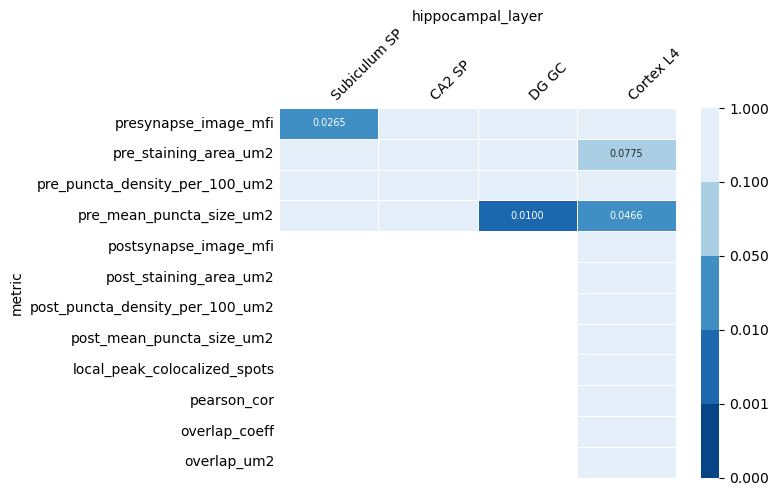

In [175]:
cmap = ListedColormap(['#084488', '#1b68ae', '#3f8ec4', '#aacfe5', "#e5eff9"])
norm = BoundaryNorm([0, 0.001, 0.01, 0.05, 0.1, 1], cmap.N)

mask = df_vglut2_2 < 0.1
annotations = df_vglut2_2.applymap(lambda x: f'{x:.4f}' if x < 0.1 else '')


ax = sns.heatmap(data=df_vglut2_2, annot=annotations, fmt = "", annot_kws={"fontsize": 7}, linewidth=0.5, vmin=0, vmax=0.1, cmap=cmap, norm=norm)

ax.xaxis.set_label_position('top')
ax.xaxis.tick_top()
plt.xticks(rotation=45, ha='left')
ax.tick_params(axis='x', length=0)
ax.tick_params(axis='y', length=0)

plt.show()

/var/folders/p5/hzbdgkws2lvg79nyhlq_g_sm0000gn/T/ipykernel_98293/2017282549.py:11: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  annotations_2 = df_2.applymap(lambda x: f'{x:.3f}' if x < 0.1 else '')
/var/folders/p5/hzbdgkws2lvg79nyhlq_g_sm0000gn/T/ipykernel_98293/2017282549.py:12: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  annotations_3 = df_vglut2_2.applymap(lambda x: f'{x:.3f}' if x < 0.1 else '')


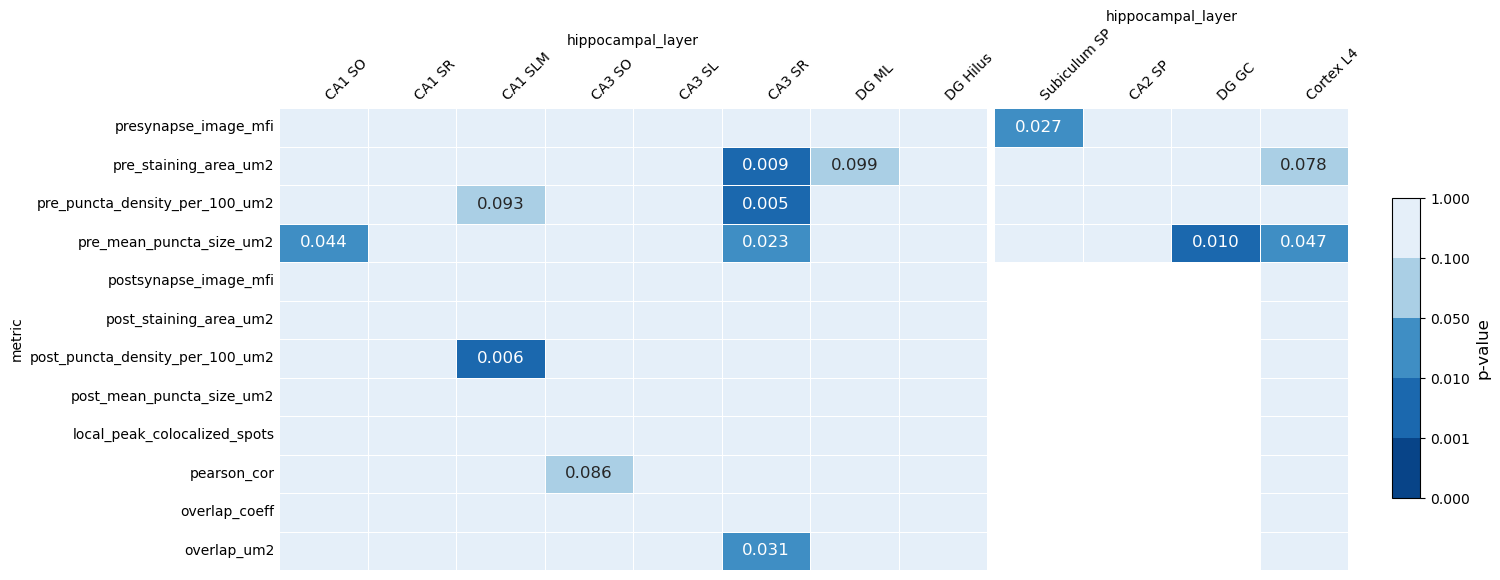

In [176]:
import matplotlib.gridspec as gridspec
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm
import seaborn as sns

# Define a discrete colormap
cmap = ListedColormap(['#084488', '#1b68ae', '#3f8ec4', '#aacfe5', "#e5eff9"])
norm = BoundaryNorm([0, 0.001, 0.01, 0.05, 0.1, 1], cmap.N)

# Format annotations with 3 decimal places
annotations_2 = df_2.applymap(lambda x: f'{x:.3f}' if x < 0.1 else '')
annotations_3 = df_vglut2_2.applymap(lambda x: f'{x:.3f}' if x < 0.1 else '')

# Set up the figure and gridspec
fig = plt.figure(figsize=(14, 6))
gs = gridspec.GridSpec(1, 3, width_ratios=[len(df_2.columns), len(df_vglut2_2.columns), 0.1], wspace=0.02)

# Create the first heatmap
ax0 = plt.subplot(gs[0])
sns.heatmap(df_2, annot=annotations_2, fmt='', annot_kws={"fontsize": 12}, linewidth=0.5, vmin=0, vmax=0.1, cmap=cmap, norm=norm, ax=ax0, cbar=False)
ax0.xaxis.set_label_position('top')
ax0.xaxis.tick_top()
ax0.tick_params(axis='x', length=0)
ax0.tick_params(axis='y', length=0)
plt.sca(ax0)
plt.xticks(rotation=45, ha='left')

# Create the second heatmap
ax1 = plt.subplot(gs[1])
heatmap = sns.heatmap(df_vglut2_2, annot=annotations_3, fmt='', annot_kws={"fontsize": 12}, linewidth=0.5, vmin=0, vmax=0.1, cmap=cmap, norm=norm, ax=ax1, cbar=False, yticklabels=False)
ax1.xaxis.set_label_position('top')
ax1.xaxis.tick_top()
ax1.tick_params(axis='x', length=0)
ax1.tick_params(axis='y', length=0)
ax1.set_ylabel('')  # Remove the y-axis label
plt.sca(ax1)
plt.xticks(rotation=45, ha='left')

# Create a separate axes for the legend
cax = fig.add_axes([0.92, 0.23, 0.02, 0.5])  # [left, bottom, width, height]
fig.colorbar(heatmap.collections[0], cax=cax, orientation='vertical')
cax.set_ylabel('p-value', fontsize=12)
cax.tick_params(labelsize=10)  # Smaller colorbar ticks

plt.show()


In [ ]:
# TODO: 
# - add also to the heatmap if its less or more then the control (up or down) -> dot plot? also include scaled difference?
#           p-value: color of the dot
#           up or down: also other color for p value OR write up (+) or down (-) in the cells
# Cannot be called up or down from a t test, only statistically significant

/var/folders/p5/hzbdgkws2lvg79nyhlq_g_sm0000gn/T/ipykernel_98293/3605568289.py:11: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  annotations_2 = df_2.applymap(lambda x: f'{x:.3f}' if x < 0.1 else '')
/var/folders/p5/hzbdgkws2lvg79nyhlq_g_sm0000gn/T/ipykernel_98293/3605568289.py:12: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  annotations_3 = df_vglut2_2.applymap(lambda x: f'{x:.3f}' if x < 0.1 else '')


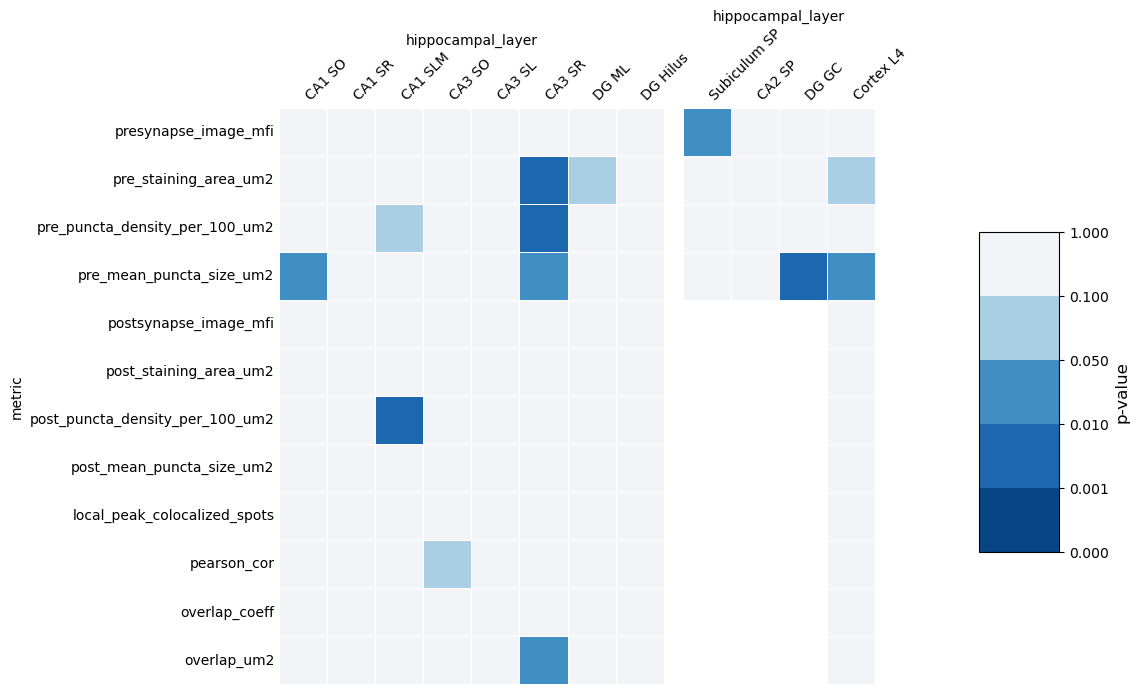

In [184]:
import matplotlib.gridspec as gridspec
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm
import seaborn as sns

# Define a discrete colormap
cmap = ListedColormap(['#084488', '#1b68ae', '#3f8ec4', '#aacfe5', "#f2f4f7"])
norm = BoundaryNorm([0, 0.001, 0.01, 0.05, 0.1, 1], cmap.N)

# Format annotations with 3 decimal places
annotations_2 = df_2.applymap(lambda x: f'{x:.3f}' if x < 0.1 else '')
annotations_3 = df_vglut2_2.applymap(lambda x: f'{x:.3f}' if x < 0.1 else '')

# Set up the figure and gridspec
fig = plt.figure(figsize=(8, 8))  # Adjust the figure size if needed
gs = gridspec.GridSpec(1, 3, width_ratios=[len(df_2.columns), len(df_vglut2_2.columns), 0.1], wspace=0.1)  # Reduced the space between plots

# Create the first heatmap
ax0 = plt.subplot(gs[0], aspect='equal')
sns.heatmap(df_2, annot=False, fmt='', annot_kws={"fontsize": 6}, linewidth=0.5, linecolor='white', vmin=0, vmax=0.1, cmap=cmap, norm=norm, ax=ax0, cbar=False)
ax0.xaxis.set_label_position('top')
ax0.xaxis.tick_top()
ax0.tick_params(axis='x', length=0)
ax0.tick_params(axis='y', length=0)
plt.sca(ax0)
plt.xticks(rotation=45, ha='left')
ax0.hlines(df_2.shape[0], *ax0.get_xlim(), color='grey', linewidth=0.5)  # Add line at the bottom
ax0.vlines(df_2.shape[1], *ax0.get_ylim(), color='grey', linewidth=0.5)  # Add line at the right

# Create the second heatmap
ax1 = plt.subplot(gs[1], aspect='equal')
heatmap = sns.heatmap(df_vglut2_2, annot=False, fmt='', annot_kws={"fontsize": 6}, linewidth=0.5, linecolor='white', vmin=0, vmax=0.1, cmap=cmap, norm=norm, ax=ax1, cbar=False, yticklabels=False)
ax1.xaxis.set_label_position('top')
ax1.xaxis.tick_top()
ax1.tick_params(axis='x', length=0)
ax1.tick_params(axis='y', length=0)
ax1.set_ylabel('')  # Remove the y-axis label
plt.sca(ax1)
plt.xticks(rotation=45, ha='left')
ax1.hlines(df_vglut2_2.shape[0], *ax1.get_xlim(), color='grey', linewidth=0.5)  # Add line at the bottom
ax1.vlines(df_vglut2_2.shape[1], *ax1.get_ylim(), color='grey', linewidth=0.5)  # Add line at the right

# Create a separate axes for the legend
cax = fig.add_axes([1, 0.3, 0.1, 0.4])  # Adjusted the height to be more centered
fig.colorbar(heatmap.collections[0], cax=cax, orientation='vertical')
cax.set_ylabel('p-value', fontsize=12)
cax.tick_params(labelsize=10)  # Smaller colorbar ticks

plt.show()

